# 1.Business name - Le Cookie Quantique 🥯🍪

Bienvenue to Le Cookie Quantique, the galaxy's first interstellar patisserie. We are dedicated to bringing the warmth and aroma of a rustic French bakery to the cold vaccum of space. While we operate as a high-tech, direct-to-customer app, our soul is made of eggs, butter and sugar.

We specialize in hand-crafting exotic, space themed treats like our gooey "Nebula Nutella" sablés and the dense, gravity-defying "Black-hole" Brownie. Once baked to perfection, we wrap them in thermal-stasis packing and dispatch our fleet of vintage styles spaceships to deliver them to your doorstep. Whether you live on Earrth, Mars or a moon of Jupiter, we ensure than a cozy, freshly baked memory is just a hyperspace jump away.

# 2.Relational Data model
 To run our intergalactic French bakery, we need to track our customers, our delicious inventory and the orders placed.










 ## 2.1. Entities

 1. Customers - to store all the customer details
 2. CookieInventory - stores information regarding our cookie inventory
 3. Orders - database to store and keep track of orders
 4. OrderItems - contains invidual line items for each order


## 2.2 Attributes and DataTypes

 Customers:

*   customer_id (INTEGER) unique id for each customer - <font color="41F0D9">PRIMARY KEY</font>
*   email (TEXT) contact email
*   name (TEXT) Customer's name
*   address (TEXT) Address of customer where the order is to be delivered

CookieInventory

*   cookie_id (INTEGER): Unique ID for each cookie type - <font color="41F0D9">PRIMARY KEY</font>
*   flavor_name (TEXT) Name of the cookie
*   price_per_dozen (INTEGER) Cost per dozen of cookies
*   contains_nuts (INTEGER) Boolean flag for allergens ,SQLite does not have a separate Boolean storage class. Instead, Boolean values are stored as integers 0 (false) and 1 (true).
*   calories (INTEGER) Calorie count per cookie
*   stock_quantiy (INTEGER) How many dozens are available
*   baked_date (TEXT) when this cookie was made, SQLite does not have a storage class set aside for storing dates and/or times.


Orders

*   order_id (INTEGER) Unique ID for each order <font color="41F0D9">PRIMARY KEY</font>
*   customer_id (INTEGER) id of the customer who placed the order <font color="D641F0">FOREIGN KEY</font>
 (links to Customers table)
*   order_date (TEXT) Date when the order was placed

OrderItems


*   item_id (INTEGER) Unique ID for a line item - <font color="41F0D9">PRIMARY KEY</font>
*   order_id (INTEGER) Links to parent order -  <font color="D641F0">FOREIGN KEY</font> (links to Orders table)
*   cookie_id (INTEGER) Links to the cookie type ordered- <font color="D641F0">FOREIGN KEY</font> (links to CookieInventory table)
*   quantity_dozens (INTEGER) Number of dozens of cookies ordered.


## 2.3. Relationship between entities

Customer  <font color="#ae2235">(1)-----> (M)</font> orders

Once customer places multiple orders, but each orde belongs to one customer only.

Orders  <font color="#ae2235">(1)-----> (M)</font>  OrderItems

One order has many orderItems in it, but a specific line items belongs to only one order.

CookieInvetory <font color="#ae2235">(1)-----> (M)</font>  OrderItems

One type of cookie can appear in many different order items across different orders



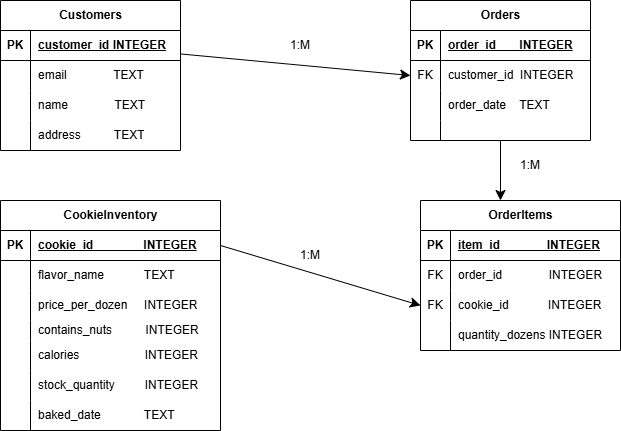

## 2.4. Normal form

The Le Cookie Quanitque database in in Third Normal Form (3NF)

1. 1NF - All columns contain atomic values. Eg: in OrdersItem, we do not list multiple cookies in a single cell, instead it is broken down so each row represents a single type of order.

2. 2NF - The table must be in 1NF anf all non-key attributes must depend on the primary key (no partial dependencies).
There are no composite primary keys Eg: in CookieInventory, the price_per_cookie depends entirely on the specific cookie_id.

3. 3NF - The table must be in 2NF, and there are no transitive dependencies. We do not store the customer's address or email in the Orders table. If we did, and the customer moved, we would have to update every single past order. Instead, Orders only contains customer_id, which points to the Customers table.


# 3.DDL

Here we are creating the 4 tables according to the above Entity Relation diagram.

In [ ]:
import sqlite3
import pandas as pd


try:
    if 'conn' in locals() and conn:
        conn.close()
except sqlite3.ProgrammingError:
    pass
conn = sqlite3.connect('le_cookie_quantique.db')
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS OrderItems")
cursor.execute("DROP TABLE IF EXISTS Orders")
cursor.execute("DROP TABLE IF EXISTS CookieInventory")
cursor.execute("DROP TABLE IF EXISTS Customers")

cursor.execute("""
CREATE TABLE Customers(
customer_id INTEGER PRIMARY KEY,
email TEXT,
name TEXT,
address TEXT);
""")

cursor.execute("""
CREATE TABLE CookieInventory(
cookie_id INTEGER PRIMARY KEY,
flavor_name TEXT,
price_per_dozen INTEGER,
contains_nuts TEXT,
calories INTEGER,
stock_quantity INTEGER,
baked_date TEXT);
""")

cursor.execute("""
CREATE TABLE Orders(
order_id INTEGER PRIMARY KEY,
customer_id INTEGER,
order_date TEXT,
FOREIGN KEY(customer_id) REFERENCES Customers(customer_id))
;
""")

cursor.execute("""
CREATE TABLE OrderItems(
item_id INTEGER PRIMARY KEY,
order_id INTEGER,
cookie_id INTEGER,
quantity_dozens INTEGER,
FOREIGN KEY(order_id) REFERENCES Orders(order_id),
FOREIGN KEY(cookie_id) REFERENCES CookieInventory(cookie_id));
""")

tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()

for table_name in tables:
  table = table_name[0]
  print(f"\nTable: {table}")
  columns = cursor.execute(f"PRAGMA table_info({table});").fetchall()
  print(f"{'Attribute':<20} | {'DataType':<10} | {'PK?'}")
  print("-" * 40)
  for col in columns:
    col_name = col[1]
    col_type = col[2]
    is_pk = col[5]
    pk_status = ""
    if is_pk == 1:
      pk_status = "PK"


    print(f"{col[1]:<20} | {col[2]:<10} | {pk_status}")


Table: Customers
Attribute            | DataType   | PK?
----------------------------------------
customer_id          | INTEGER    | PK
email                | TEXT       | 
name                 | TEXT       | 
address              | TEXT       | 

Table: CookieInventory
Attribute            | DataType   | PK?
----------------------------------------
cookie_id            | INTEGER    | PK
flavor_name          | TEXT       | 
price_per_dozen      | INTEGER    | 
contains_nuts        | TEXT       | 
calories             | INTEGER    | 
stock_quantity       | INTEGER    | 
baked_date           | TEXT       | 

Table: Orders
Attribute            | DataType   | PK?
----------------------------------------
order_id             | INTEGER    | PK
customer_id          | INTEGER    | 
order_date           | TEXT       | 

Table: OrderItems
Attribute            | DataType   | PK?
----------------------------------------
item_id              | INTEGER    | PK
order_id             | INTEGER    | 


# 4.DML
Here we are inserting fake data into each of the columns of the 4 tables and then updating the stock quantity of Nebula Nutella Sablé cookie in the CookieInventory table.

In [ ]:
cursor.execute("INSERT INTO Customers VALUES(1,'picard@starfleet.fr','Rohan Picard','Taj Mahal INDIA Earth')")
cursor.execute("INSERT INTO Customers VALUES(2,'maxiene@yipee.com','Maxiene 2.0er','Spock Verse Venus')")
cursor.execute("INSERT INTO Customers VALUES(3,'whydoweneedemails@towel.fed','Sandy Theed','Leeloo Vulcan')")
cursor.execute("INSERT INTO Customers VALUES(4,'orangeBananas@starfleet.fr','Random Joe','123 Gate island Bahamas Earth')")
cursor.execute("INSERT INTO Customers VALUES(5,'prabhaladhan@redplanet.now','Prabhalandan Nambiar','Colony 23 Mars')")

In [ ]:
cursor.execute("INSERT INTO CookieInventory VALUES (101, 'Nebula Nutella Sablé', 18, 1, 480, 100,'2023-10-01')")
cursor.execute("INSERT INTO CookieInventory VALUES (102, 'Black-Hole Brownie', 14, 0, 500, 50, '2023-10-02')")
cursor.execute("INSERT INTO CookieInventory VALUES (103, 'Macaron de Mars', 22, 1, 150, 200,  '2023-10-02')")
cursor.execute("INSERT INTO CookieInventory VALUES (104, 'Supernova Soufflé', 20, 0, 350, 20, '2023-10-03')")
cursor.execute("INSERT INTO CookieInventory VALUES (105, 'Croissant of the Cosmos', 12, 0, 280, 40, '2023-10-03')")

In [ ]:
cursor.execute("INSERT INTO Orders VALUES (5001,1,'2023-10-01')")
cursor.execute("INSERT INTO Orders VALUES (5002,2,'2023-10-01')")
cursor.execute("INSERT INTO Orders VALUES (5003,3,'2023-10-21')")
cursor.execute("INSERT INTO Orders VALUES (5004,4,'2023-11-01')")
cursor.execute("INSERT INTO Orders VALUES (5005,3,'2023-10-16')")
cursor.execute("INSERT INTO Orders VALUES (5006,4,'2023-10-22')")
cursor.execute("INSERT INTO Orders VALUES (5007,5,'2023-10-17')")
cursor.execute("INSERT INTO Orders VALUES (5008,5,'2023-10-05')")

In [ ]:
cursor.execute("INSERT INTO OrderItems VALUES (1, 5001, 101, 2)")
cursor.execute("INSERT INTO OrderItems VALUES (2, 5002, 102, 2)")
cursor.execute("INSERT INTO OrderItems VALUES (3, 5002, 104, 1)")
cursor.execute("INSERT INTO OrderItems VALUES (4, 5003, 104, 1)")
cursor.execute("INSERT INTO OrderItems VALUES (5, 5004, 104, 3)")

In [ ]:
before_value = cursor.execute("SELECT stock_quantity FROM CookieInventory WHERE flavor_name = 'Nebula Nutella Sablé'").fetchone()
print(f"Stock for Nebula Nutella before update : {before_value[0]}")

Stock for Nebula Nutella before update : 100


In [ ]:
cursor.execute("""
UPDATE CookieInventory
SET stock_quantity = stock_quantity+ 50
WHERE flavor_name = 'Nebula Nutella Sablé'
""")
conn.commit()
after_value = cursor.execute("SELECT stock_quantity FROM CookieInventory WHERE flavor_name = 'Nebula Nutella Sablé'").fetchone()
print(f"Stock for Nebula Nutella after update: {after_value[0]}")

Stock for Nebula Nutella after update: 150


# 5.Query

I would like to ask the below 3 questions to our data.



### 5.1. Question 1 :-
### How many allergen free options do we have?

In [ ]:
print("---- List of allergen-free cookies----")
sql_q1 = """
SELECT flavor_name
FROM CookieInventory
WHERE contains_nuts IS 0
"""
df_q1 = pd.read_sql_query(sql_q1,conn)
print(df_q1)

---- List of allergen-free cookies----
               flavor_name
0       Black-Hole Brownie
1        Supernova Soufflé
2  Croissant of the Cosmos


### 5.2. Question 2:-

### Who is our VIP customer? (Who purchased the most items)
We look for customer who bought the maximum number (highest quantity_dozens)


Here we are connecting three different tables to trace the path from a person to the products they bought.

First, we join Customers with Orders using the customer_id. This links every order to the specific person who placed it.

Next, we join those Orders with OrderItems using the order_id. This reveals exactly what was inside each of those orders (the specific cookies and quantities).

By chaining these three tables together (Customers -> Orders -> OrderItems), we can calculate the total number of items purchased for each specific customer

In [ ]:
print("----  OUR 👑 VIP customer----")
sql_q2 = """
SELECT
cust.name,
SUM(item.quantity_dozens) as total_items_purchased
FROM Customers cust
JOIN Orders o ON cust.customer_id = o.customer_id
JOIN OrderItems item ON o.order_id = item.order_id
GROUP BY cust.name
ORDER BY total_items_purchased DESC
LIMIT 1;
"""
df_q2 = pd.read_sql_query(sql_q2,conn)
print(df_q2)

----  OUR 👑 VIP customer----
         name  total_items_purchased
0  Random Joe                      3


## 5.3. Question 3:-

### What is the most popular cookie flavor?
What cookie has been sold in the highest quantities?

We are connecting the CookieInventory table (which has the flavor names) to the OrderItems table (which has the sales numbers).

We match them using the cookie_id column found in both tables.

This allows us to replace the ID number of the Cookie (like 101) with the actual name (like Nebula Nutella Sablé) so we can see exactly which flavor is selling the most boxes.

In [ ]:
print("----  OUR  most 💗-ed cookie yet 🥁----")
sql_q3 = """
SELECT
cookie.flavor_name,
SUM(item.quantity_dozens) as total_boxes_sold
FROM CookieInventory cookie
JOIN OrderItems item ON cookie.cookie_id = item.cookie_id
GROUP BY cookie.flavor_name
ORDER BY total_boxes_sold DESC
LIMIT 1;
"""
df_q3 = pd.read_sql_query(sql_q3,conn)
print(df_q3)

----  OUR  most 💗-ed cookie yet 🥁----
         flavor_name  total_boxes_sold
0  Supernova Soufflé                 5


## 5.4. Question 4:-

What is our most expensive cookie?

In [ ]:
print("----  OUR most $$$ expensive cookie----")
sql_q4 = """
SELECT flavor_name, MAX(price_per_dozen)
as highest_price
FROM CookieInventory;
"""
df_q4 = pd.read_sql_query(sql_q4,conn)
print(df_q4)

----  OUR most $$$ expensive cookie----
       flavor_name  highest_price
0  Macaron de Mars             22


## 5.5 How to apply more complex data science algorithm on top of this data

To take Le Cookie Quantique to the next level, I would deploy Association Rule Mining to unlock the secrets of intergalactic cravings. This would be done by analyzing the OrderItems table. The algorithm would look for patterns like "Customers who but the Nebula Nutella are 80% likey to also but Macaron de Mars". This would help "Le Cookie Quantique" to build a predictive recommendation engine on the app ( eg: maybe asking them  something like, "Did you forget to add Macarons to your order?" or "we think you would like this")  promising a delicious experience for every creature, across every timeline in the universe or multiverse perhaps?! 🌌🚀

# 6.Scale

<font color="#ae2235">**Phase 1**</font> : As Le Cookie Quantiquw grows from a local startup to a galactic enterpise, SQLite database will hit a wall. One of the major disadvantages of using SQLite is its limited scalability. It is designed to handle small to medium-sized databases, and its performance degrades when dealing with large amounts of data or multiple concurrent users. So we will have to migrate to a Client - Server RDBMS like PostgreSQL or mySQl. These databases are designed to handle concurrency. They would allow hundreds of users to read and write data at the exact same without locking the whole system like SQLite. They also offer better security, user roles and runs on a dedicated server distinct from the application code.


<font color="#ae2235">**Phase 2**</font>:  Eventually, our customer base will generate more data than a single hardrive can hold. We have 2 options here to scale:









##6.1. Option 1

1️⃣  Master - Slave Architecture
We keep one primary database for writing new orders (INSERT/UPDATE) and maybe create several READ-ONLY copies for users who are just browsing the menu ( SELECT).


This is an ideal strategy because for most e-commerce websties more than 70 percent poeple mostly browse (READ) and the only rest 30 percent or so actually clicks on buy now (WRITE).


The tradeoff here would be the latency, for instance, when a cookie goes out of stock on the primary database and that information reaching the replicas, the customer might try to buy a cookie that just went out of stock a few minutes ago.


So this is why we would think of an option B.

##6.2. Option 2

2️⃣  Horizontal partitioning

We split our data across multiple servers based on a specific key like planetry system.

Partition 1 : store customer/orders from Earth

Partition 1 : store customer/orders from Mars

Partition 1 : store customer/orders from Vulcan

Since we are an intergalatic business, Data Locality is crucial. Storing Mars' data on a server located on Mars reduces the "speed of light" latency for those users.

A major tradeoff here is Data Skew. Not all planets are equal. Earth might have 10 billion hungry customers, while Mars only has a small colony of 500 scientists. If we shrad by planet, the Earth server will be constantly overloaded, while the Mars Server sits mostly idle comparatively and waste money. This uneven distribution makes resource management inefficient and could lead to crashes on our most popular planet. So we would have to break the *one-planet = one-server* rule and split regions which makes the logic more complicated for the app as it would need a map to figure out exactly which Earth server is the customer on.